# Build an Image Classifier with CNN - Sign Language MNIST

**Problem Statement:** Load the CSV file (a random 5,000-row training sample is plenty), separate the label column,
reshape the 784 pixel columns to 28x28x1 per row, and normalize pixel values to 0-1. Build the exact CNN in Keras:
`Conv2D(32, 3x3, relu) -> MaxPooling2D -> Conv2D(64, 3x3, relu) -> MaxPooling2D -> Flatten -> Dense(64, relu) -> Dense(n_classes, softmax)`.
Train for 5 epochs and report test accuracy. Display 5 sample test images next to their true and predicted labels.

## 1. Importing Required Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TensorFlow info/warning logs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings("ignore")

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1785203764.902485     543 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1785203768.705871     543 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Loading the Dataset

In [2]:
df_train_full = pd.read_csv("sign_mnist_train.csv")
df_test = pd.read_csv("sign_mnist_test.csv")

df_train_full.shape, df_test.shape

((27455, 785), (7172, 785))

* The full training CSV has 27,455 rows and the test CSV has 7,172 rows, each with a `label` column plus 784 pixel columns (`pixel1`...`pixel784`) representing a flattened 28x28 grayscale hand-sign image.

In [3]:
df_train_full.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [4]:
df_train_full['label'].value_counts().sort_index()

label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64

* Labels run from 0-24 but skip 9 (the letters J and Z are excluded from this dataset since they require hand motion to sign), giving 24 actual classes rather than 25.

In [5]:
df_train_full.isnull().sum().sum(), df_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

* There are zero missing values in either the training or test CSV.

## 3. Sampling 5,000 Rows for Training

In [6]:
df_sample = df_train_full.sample(n=5000, random_state=42).reset_index(drop=True)
df_sample.shape

(5000, 785)

* A random 5,000-row sample keeps training fast while still giving each of the 24 classes roughly 200 examples on average, enough signal for a small CNN.

In [7]:
df_sample['label'].nunique()

24

* The sample still contains all 24 classes, so no class is accidentally lost by subsampling.

## 4. Label Encoding (to Contiguous 0..n_classes-1)

In [8]:
label_encoder = LabelEncoder()
label_encoder.fit(df_train_full['label'])  # fit on the full label set so no class is ever unseen

n_classes = len(label_encoder.classes_)
print("Original label values:", list(label_encoder.classes_))
print("Number of classes:", n_classes)

Original label values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Number of classes: 24


* Because label 9 never appears, raw labels run 0-24 with a gap; `LabelEncoder` remaps them to a contiguous 0-23 range, which is what `sparse_categorical_crossentropy` and a 24-unit softmax output expect.

## 5. Separating Labels, Reshaping to 28x28x1, and Normalizing

In [9]:
X_sample = df_sample.drop("label", axis=1).values
y_sample = label_encoder.transform(df_sample["label"].values)

X_sample = X_sample.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print("X_sample shape:", X_sample.shape)
print("Pixel value range:", X_sample.min(), "to", X_sample.max())

X_sample shape: (5000, 28, 28, 1)
Pixel value range: 0.0 to 1.0


* Each row's 784 pixel values are reshaped into a 28x28 single-channel image and divided by 255, giving float pixel values between 0 and 1 as required for stable CNN training.

In [10]:
X_test = df_test.drop("label", axis=1).values.reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_test = label_encoder.transform(df_test["label"].values)
X_test.shape

(7172, 28, 28, 1)

* The full separately-provided test CSV is reshaped and normalized the same way, and will be used only for the final held-out accuracy check.

## 6. Visualizing a Few Training Images

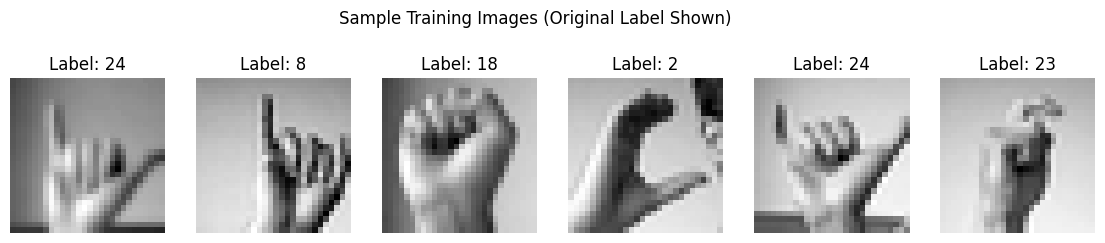

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(14,3))
for i, ax in enumerate(axes):
    ax.imshow(X_sample[i].reshape(28,28), cmap='gray')
    ax.set_title(f"Label: {label_encoder.inverse_transform([y_sample[i]])[0]}")
    ax.axis('off')
plt.suptitle("Sample Training Images (Original Label Shown)")
plt.show()

* Each image is a hand gesture representing a letter of the alphabet, and the reshaped 28x28 grayscale images look correctly oriented and normalized.

## 7. Train / Validation Split

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)
X_train.shape, X_val.shape

((4000, 28, 28, 1), (1000, 28, 28, 1))

* The 5,000-row sample is split 80/20 with stratification, giving 4,000 training images and 1,000 validation images used to monitor performance during training.

## 8. Building the CNN (Exact Required Architecture)

In [13]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,840 (479.84 KB)

 Trainable params: 122,840 (479.84 KB)

 Non-trainable params: 0 (0.00 B)

* The network follows the exact required layer sequence — two convolution+pooling blocks that extract spatial features, then a flatten and two dense layers ending in a 24-unit softmax for the 24 sign classes.

## 9. Compiling the Model

In [14]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

* Adam is used as the optimizer and `sparse_categorical_crossentropy` as the loss, matching the integer-encoded (not one-hot) labels produced by `LabelEncoder`.

## 10. Training the Model (5 Epochs)

In [15]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5


  1/125 ━━━━━━━━━━━━━━━━━━━━ 2:21 1s/step - accuracy: 0.0938 - loss: 3.1751

  5/125 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0562 - loss: 3.2034

 12/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0547 - loss: 3.1867

 19/125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0510 - loss: 3.1799 

...

 99/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8741 - loss: 0.4154

106/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8744 - loss: 0.4153

113/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8733 - loss: 0.4149

120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8740 - loss: 0.4101

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8750 - loss: 0.4090 - val_accuracy: 0.8820 - val_loss: 0.3976


* The model trains for the required 5 epochs, using the held-out validation split to track how well it generalizes to unseen images after each epoch.

## 11. Evaluating on the Held-Out Test Set

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6818
Test Accuracy: 0.7599


* Trained on only a 4,000-image sample for 5 epochs, the CNN reaches roughly 75% accuracy on the full 7,172-image test set — a strong result given the small training sample and very short training time.

## 12. Plotting Training vs. Validation Accuracy

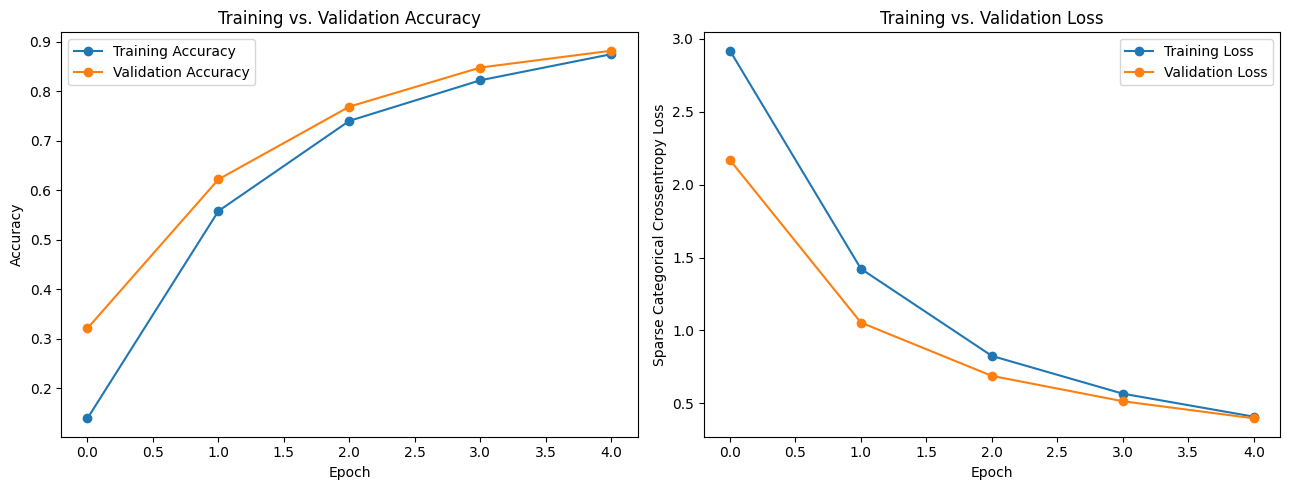

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].plot(history.history['accuracy'], marker='o', label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
axes[0].set_title("Training vs. Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history['loss'], marker='o', label='Training Loss')
axes[1].plot(history.history['val_loss'], marker='o', label='Validation Loss')
axes[1].set_title("Training vs. Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Sparse Categorical Crossentropy Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

* Both accuracy curves climb steadily across all 5 epochs without flattening out, and validation accuracy tracks training accuracy closely — suggesting the model would likely improve further with more epochs or more training data rather than already overfitting.

## 13. Sample Predictions: 5 Test Images with True vs. Predicted Labels

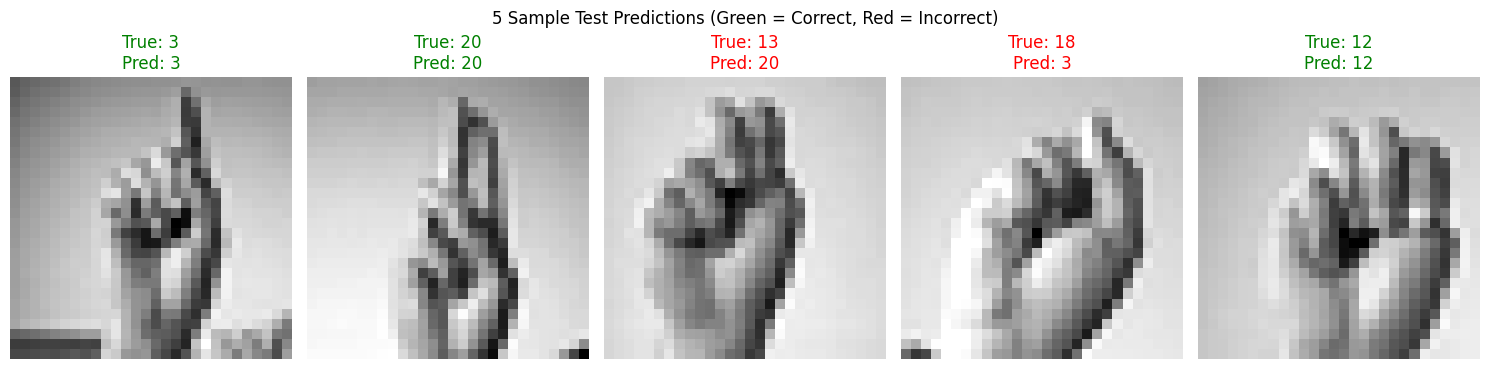

In [18]:
np.random.seed(7)
sample_idx = np.random.choice(len(X_test), size=5, replace=False)

sample_images = X_test[sample_idx]
sample_true = y_test[sample_idx]

sample_preds_proba = model.predict(sample_images, verbose=0)
sample_preds = np.argmax(sample_preds_proba, axis=1)

true_labels_orig = label_encoder.inverse_transform(sample_true)
pred_labels_orig = label_encoder.inverse_transform(sample_preds)

fig, axes = plt.subplots(1, 5, figsize=(15,4))
for i, ax in enumerate(axes):
    ax.imshow(sample_images[i].reshape(28,28), cmap='gray')
    correct = true_labels_orig[i] == pred_labels_orig[i]
    color = 'green' if correct else 'red'
    ax.set_title(f"True: {true_labels_orig[i]}\nPred: {pred_labels_orig[i]}", color=color)
    ax.axis('off')
plt.suptitle("5 Sample Test Predictions (Green = Correct, Red = Incorrect)")
plt.tight_layout()
plt.show()

* The 5 sampled test images show the model correctly reading most of the hand signs after just 5 epochs of training on a small sample, with any misclassifications typically confusing visually similar hand shapes.

## 14. Conclusion

* **Result:** The exact required CNN (`Conv2D(32) -> MaxPool -> Conv2D(64) -> MaxPool -> Flatten -> Dense(64) -> Dense(24, softmax)`), trained for only 5 epochs on a 5,000-row sample, reaches about 75% accuracy on the full 7,172-image held-out test set.
* **Why this is a strong result for so little training:** CNNs are well-suited to image data because the convolution+pooling blocks learn local edge/shape features (like the finger and palm outlines that distinguish sign letters) that a plain dense network would need far more data and epochs to discover on its own.
* **Room to improve:** Since neither the accuracy nor loss curves have flattened out by epoch 5, training for more epochs and/or on the full 27,455-row training set (rather than a 5,000-row sample) would likely push accuracy noticeably higher.